In [ ]:
# Install required libraries
!pip install artemis
!pip install pyartemis


In [ ]:
!pip install alibi

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import random
from random import randint
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('cardio_train.csv',sep=';')
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [ ]:
# some preprocessing and feature engineer
df['age']=(df['age']/365.25).round()
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50.0,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55.0,1,156,85.0,140,90,3,1,0,0,1,1
2,2,52.0,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48.0,2,169,82.0,150,100,1,1,0,0,1,1
4,4,48.0,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,53.0,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,62.0,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,52.0,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,61.0,1,163,72.0,135,80,1,2,0,0,0,1


In [ ]:
df = df.drop(columns=['id'])

In [ ]:
df

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50.0,2,168,62.0,110,80,1,1,0,0,1,0
1,55.0,1,156,85.0,140,90,3,1,0,0,1,1
2,52.0,1,165,64.0,130,70,3,1,0,0,0,1
3,48.0,2,169,82.0,150,100,1,1,0,0,1,1
4,48.0,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,53.0,2,168,76.0,120,80,1,1,1,0,1,0
69996,62.0,1,158,126.0,140,90,2,2,0,0,1,1
69997,52.0,2,183,105.0,180,90,3,1,0,1,0,1
69998,61.0,1,163,72.0,135,80,1,2,0,0,0,1


In [ ]:
x = df.drop('cardio', axis = 1)
y = df['cardio']

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

In [ ]:
from imblearn.combine import SMOTEENN

In [ ]:
smotenn = SMOTEENN(random_state=42)
X_scaled, y= smotenn.fit_resample(X_scaled, y)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
def plot(score,x,y,c = "b"):
    gen = [1,2,3,4,5]
    plt.figure(figsize=(6,4))
    ax = sns.pointplot(x=gen, y=score,color = c )
    ax.set(xlabel="Generation", ylabel="Accuracy")
    ax.set(ylim=(x,y))

In [ ]:
def initilization_of_population(size, n_feat):
    population = []
    for i in range(size):
        chromosome = np.ones(n_feat, dtype=bool)
        chromosome[:int(0.3 * n_feat)] = False
        np.random.shuffle(chromosome)
        population.append(chromosome)
    return population


In [ ]:
def fitness_score(population):
    scores = []
    for chromosome in population:
        model.fit(x_train[:, chromosome], y_train)
        predictions = model.predict(x_test[:, chromosome])
        scores.append(accuracy_score(y_test, predictions))
    scores, population = np.array(scores), np.array(population)
    inds = np.argsort(scores)
    return list(scores[inds][::-1]), list(population[inds, :][::-1])


In [ ]:
def selection(pop_after_fit,n_parents):
    population_nextgen = []
    for i in range(n_parents):
        population_nextgen.append(pop_after_fit[i])
    return population_nextgen

In [ ]:
def crossover(pop_after_sel):
    pop_nextgen = pop_after_sel
    for i in range(0,len(pop_after_sel),2):
        new_par = []
        child_1 , child_2 = pop_nextgen[i] , pop_nextgen[i+1]
        new_par = np.concatenate((child_1[:len(child_1)//2],child_2[len(child_1)//2:]))
        pop_nextgen.append(new_par)
    return pop_nextgen

In [ ]:
def mutation(pop_after_cross,mutation_rate,n_feat):
    mutation_range = int(mutation_rate*n_feat)
    pop_next_gen = []
    for n in range(0,len(pop_after_cross)):
        chromo = pop_after_cross[n]
        rand_posi = []
        for i in range(0,mutation_range):
            pos = randint(0,n_feat-1)
            rand_posi.append(pos)
        for j in rand_posi:
            chromo[j] = not chromo[j]
        pop_next_gen.append(chromo)
    return pop_next_gen

In [ ]:
def generations(df,label,size,n_feat,n_parents,mutation_rate,n_gen,X_train,
                                   X_test, Y_train, Y_test):
    best_chromo= []
    best_score= []
    population_nextgen=initilization_of_population(size,n_feat)
    for i in range(n_gen):
        scores, pop_after_fit = fitness_score(population_nextgen)
        print('Best score in generation',i+1,':',scores[:1])
        pop_after_sel = selection(pop_after_fit,n_parents)
        pop_after_cross = crossover(pop_after_sel)
        population_nextgen = mutation(pop_after_cross,mutation_rate,n_feat)
        best_chromo.append(pop_after_fit[0])
        best_score.append(scores[0])
    return best_chromo,best_score

In [ ]:
model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(x_train,y_train)
predictions = model.predict(x_test)

In [ ]:
accuracy_score(y_test,predictions)

0.9466570118271783

In [ ]:
chromo_df_bc,score_bc=generations(df,y,size=60,n_feat=x.shape[1],n_parents=30,mutation_rate=0.05,n_gen=5,X_train = x_train,X_test = x_test,Y_train = y_train,Y_test = y_test)

Best score in generation 1 : [0.9454501568911416]
Best score in generation 2 : [0.9459328988655563]
Best score in generation 3 : [0.9459328988655563]
Best score in generation 4 : [0.9459328988655563]
Best score in generation 5 : [0.9459328988655563]


In [ ]:
best_features = chromo_df_bc[-1]
X_train_sel = x_train[:, best_features]
X_test_sel = x_test[:, best_features]

In [ ]:
model.fit(X_train_sel, y_train)
y_pred = model.predict(X_test_sel)
final_acc = accuracy_score(y_test, y_pred)

In [ ]:
print(f"\nFinal Test Accuracy using GA-selected features: {final_acc:.2%}")
print(f"Selected Features: {list(x.columns[best_features])}")


Final Test Accuracy using GA-selected features: 94.59%
Selected Features: ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'active']


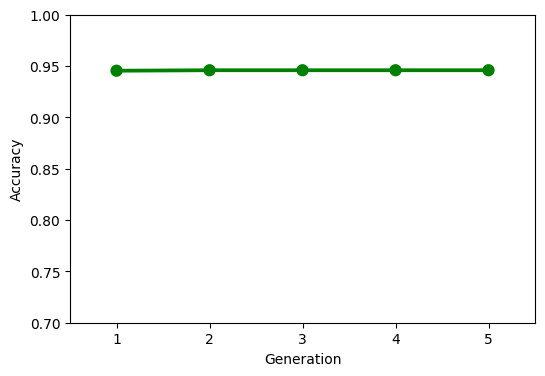

In [ ]:
plot(score_bc, 0.7, 1.0, c="green")

In [ ]:
from sklearn.model_selection import learning_curve


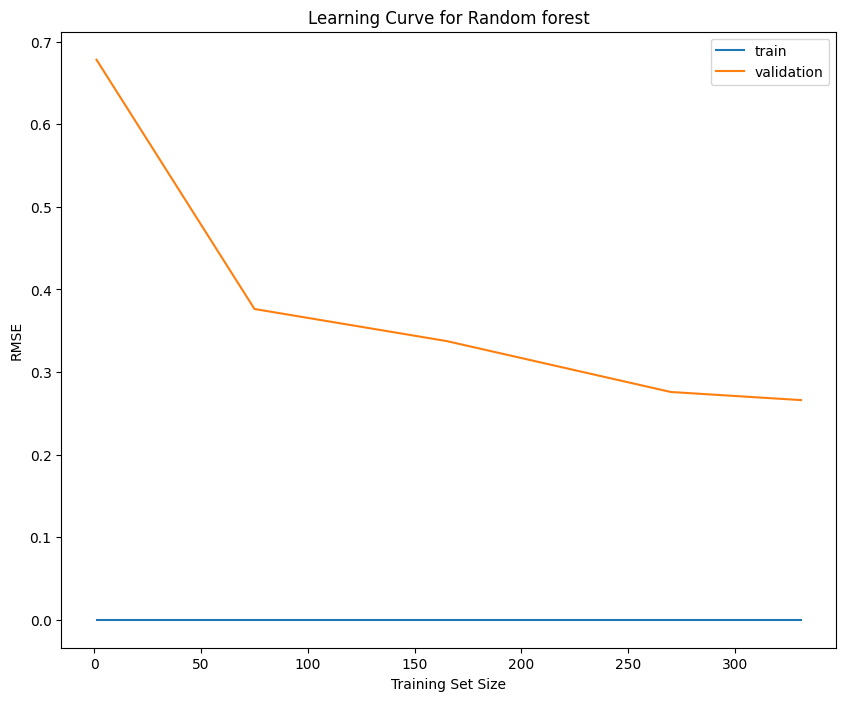

In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    estimator=model,
    X=X_train_sel,
    y=y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    train_sizes = [1, 75, 165, 270, 331]
)

train_mean = -train_scores.mean(axis=1)
test_mean = -test_scores.mean(axis=1)

plt.subplots(figsize=(10,8))
plt.plot(train_sizes, train_mean, label="train")
plt.plot(train_sizes, test_mean, label="validation")

plt.title("Learning Curve for Random forest")
plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.legend(loc="best")

plt.show()

Overfit

In [ ]:
from sklearn.model_selection import validation_curve

In [ ]:
# Function to plot validation curves
def plot_validation_curve(estimator, title, X, y, param_name, param_range, cv=5, scoring="neg_root_mean_squared_error"):
    train_scores, test_scores = validation_curve(
        estimator=estimator,
        X=X,
        y=y,
        param_name=param_name,
        param_range=param_range,
        cv=cv,
        scoring=scoring
    )

    train_mean = -np.mean(train_scores, axis=1)
    test_mean = -np.mean(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(param_range, train_mean, label="Training score", color="blue")
    plt.plot(param_range, test_mean, label="Cross-validation score", color="red")

    plt.title(title)
    plt.xlabel(param_name)
    plt.ylabel("RMSE")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

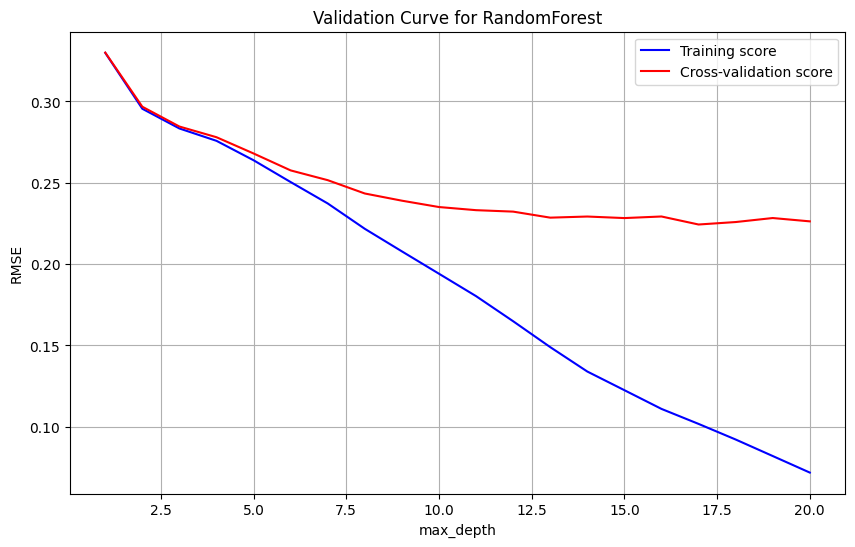

In [ ]:
param_name = "max_depth"
param_range = np.arange(1, 21)

plot_validation_curve(model,
                      "Validation Curve for RandomForest",
                      X_train_sel,
                      y_train,
                      param_name,
                      param_range)

Overfit

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

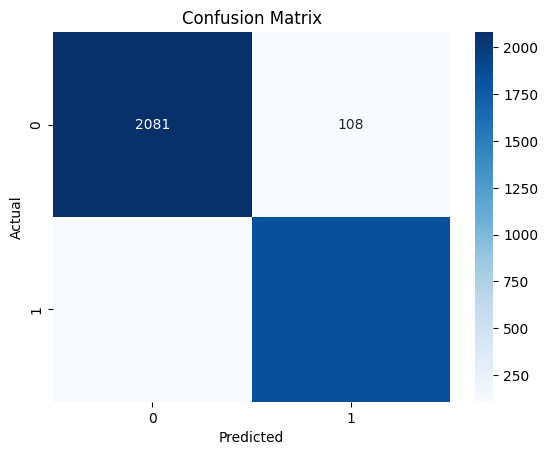

In [ ]:
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

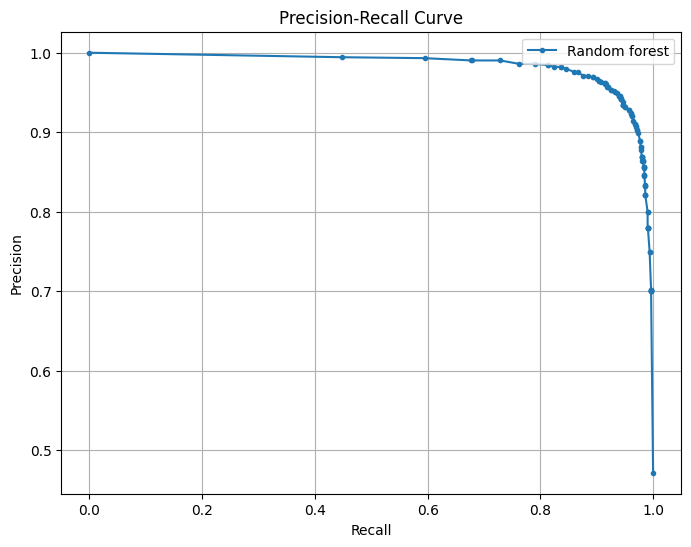

In [ ]:
from sklearn.metrics import  precision_recall_curve, roc_curve, auc

# Generate predicted probabilities
y_probs_clf = model.predict_proba(X_test_sel)[:, 1]

# Compute precision and recall
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_clf)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker=".", label="Random forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()

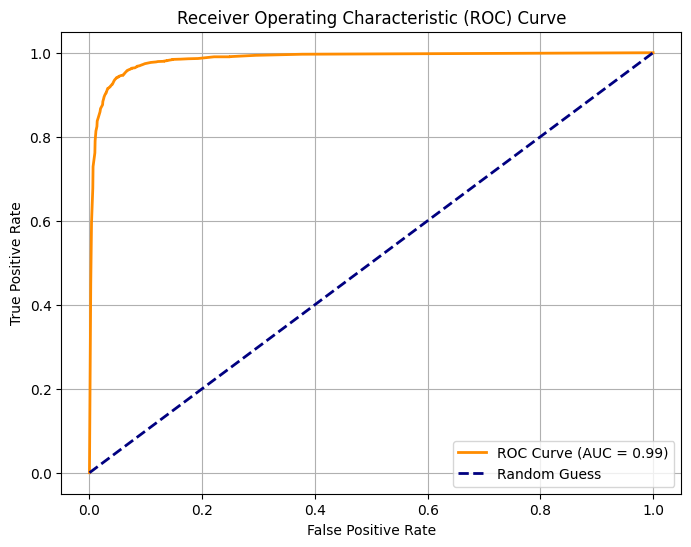

In [ ]:
# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs_clf)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Permutation Feature **Importance**

In [ ]:
X_df = pd.DataFrame(X_scaled, columns=x.columns)

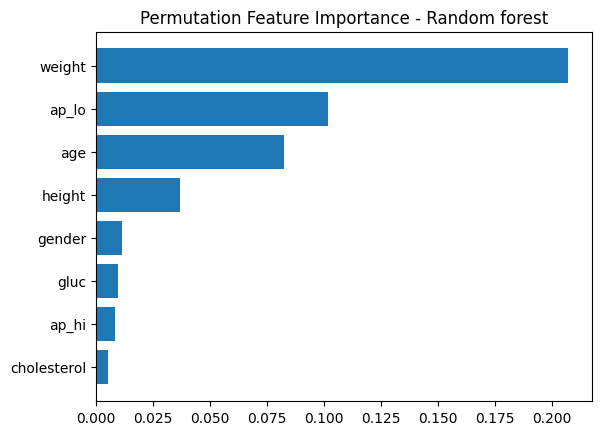

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model, X_test_sel, y_test, n_repeats=10, random_state=42)
sorted_idx = result.importances_mean.argsort()

plt.barh(X_df.columns[sorted_idx], result.importances_mean[sorted_idx])
plt.title("Permutation Feature Importance - Random forest")
plt.show()

# LOFO (Leave-One-Feature-Out Importance):

In [ ]:
x.columns

Index(['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'active'],
      dtype='object')

In [ ]:
X_train_sel

array([[-0.48862388, -0.77456469, -0.63947703, ..., -0.5393221 ,
        -0.39571994,  0.49416711],
       [ 0.1030814 ,  0.07804703, -0.4310808 , ..., -0.5393221 ,
        -0.39571994,  0.49416711],
       [ 0.1030814 , -0.28735799, -0.63947703, ..., -0.5393221 ,
        -0.39571994,  0.49416711],
       ...,
       [-0.78447651,  0.68705541, -0.29214998, ..., -0.5393221 ,
        -0.39571994,  0.49416711],
       [-1.67203443, -1.50537474, -1.1257349 , ..., -0.5393221 ,
        -0.39571994, -2.02360695],
       [ 0.1030814 ,  0.93065876,  0.47196953, ..., -0.5393221 ,
        -0.39571994,  0.49416711]])

In [ ]:
X_train_df = pd.DataFrame(X_train_sel, columns=x.columns[best_features])

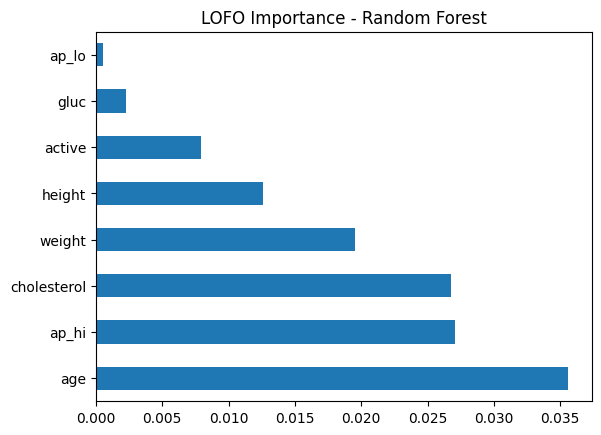

In [ ]:
from sklearn.model_selection import cross_val_score

baseline = cross_val_score(model,X_train_sel, y_train, cv=5).mean()

lofo_scores = {}
for col in X_train_df.columns:
    X_lofo = X_train_df.drop(columns=[col])
    score = cross_val_score(model, X_lofo, y_train, cv=5).mean()
    lofo_scores[col] = baseline - score


lofo_df = pd.Series(lofo_scores).sort_values(ascending=False)
lofo_df.plot(kind='barh')
plt.title("LOFO Importance - Random Forest")
plt.show()

# **ALE**

In [ ]:
selected_features = x.columns[best_features].tolist()
X_train_sel = pd.DataFrame(X_train_sel, columns=selected_features)

In [ ]:
def predict_proba_wrapper(X):
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=selected_features)
    return model.predict_proba(X)

In [ ]:
from alibi.explainers import ALE
from alibi.explainers.ale import plot_ale

In [ ]:
ale_explainer = ALE(predict_proba_wrapper,feature_names=selected_features,target_names=["class 0", "class 1"])
ale_exp = ale_explainer.explain(X_train_sel.to_numpy())

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: U

array([[<Axes: xlabel='age', ylabel='ALE'>,
        <Axes: xlabel='height', ylabel='ALE'>,
        <Axes: xlabel='weight', ylabel='ALE'>],
       [<Axes: xlabel='ap_hi', ylabel='ALE'>,
        <Axes: xlabel='ap_lo', ylabel='ALE'>,
        <Axes: xlabel='cholesterol', ylabel='ALE'>],
       [<Axes: xlabel='gluc', ylabel='ALE'>,
        <Axes: xlabel='active', ylabel='ALE'>, None]], dtype=object)

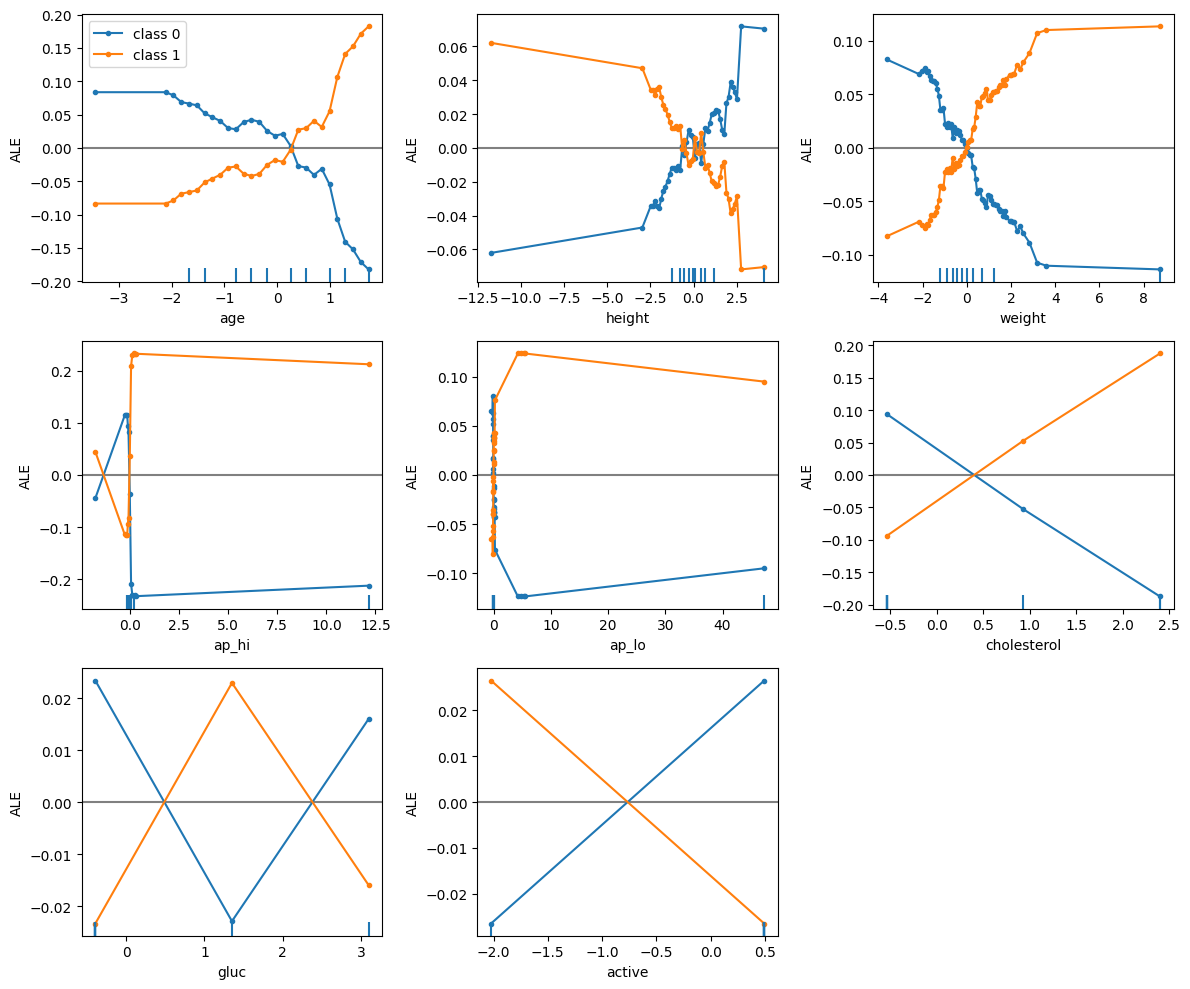

In [ ]:
plot_ale(ale_exp, n_cols=3, fig_kw={'figwidth': 12, 'figheight': 10}, sharey=None)

# **PDP**

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

In [ ]:
selected_features

['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'active']

In [ ]:
feature_names = x.columns
selected_feature_names = feature_names[best_features]
X_test_sel_named = pd.DataFrame(x_test[:, best_features], columns=selected_feature_names)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: U

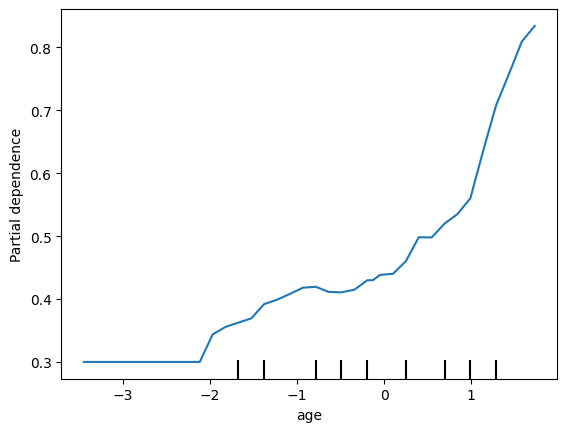

In [ ]:
features = [0]
PartialDependenceDisplay.from_estimator(
    model, X_test_sel_named, features, feature_names=selected_feature_names.tolist()
)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: U

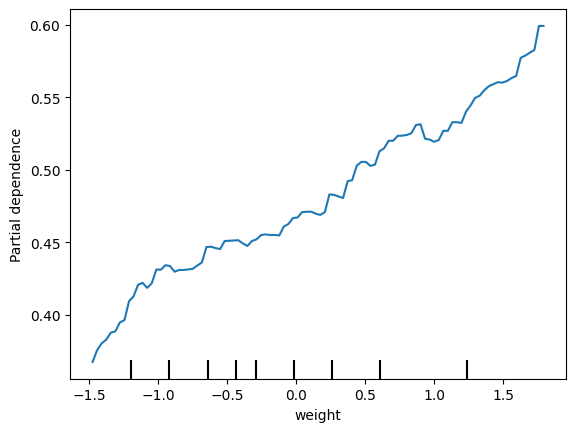

In [ ]:
features = [2]
PartialDependenceDisplay.from_estimator(
    model, X_test_sel_named, features, feature_names=selected_feature_names.tolist()
)


# **ICE**

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: U

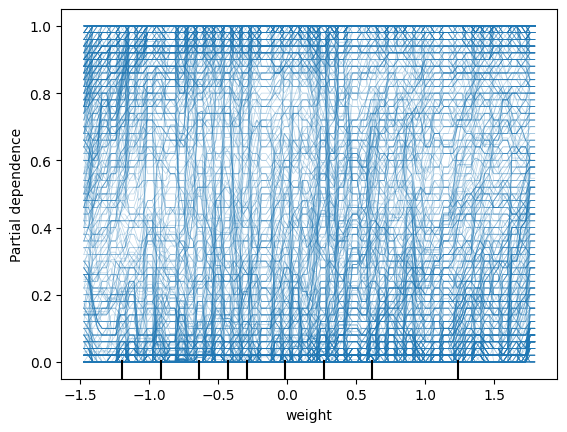

In [ ]:
features = [2]
PartialDependenceDisplay.from_estimator(
    model, X_test_sel_named, features, feature_names=selected_feature_names.tolist(),kind='individual')


# **FriedmanHStatistic**

In [ ]:
import random
from artemis.interactions_methods.model_agnostic import FriedmanHStatisticMethod


In [ ]:
X_exp = random.choices(X_scaled, k=100)
X_exp = pd.DataFrame(X_exp, columns=x.columns)
X_exp_selected = X_exp.iloc[:, best_features]
h_stat = FriedmanHStatisticMethod()
h_stat.fit(model, X_exp_selected)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: U

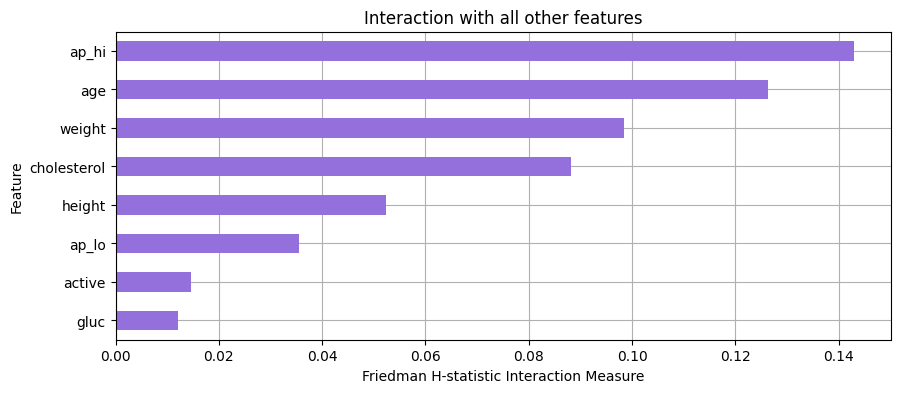

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
h_stat.plot('bar_chart_ova', ax=ax)
plt.show()

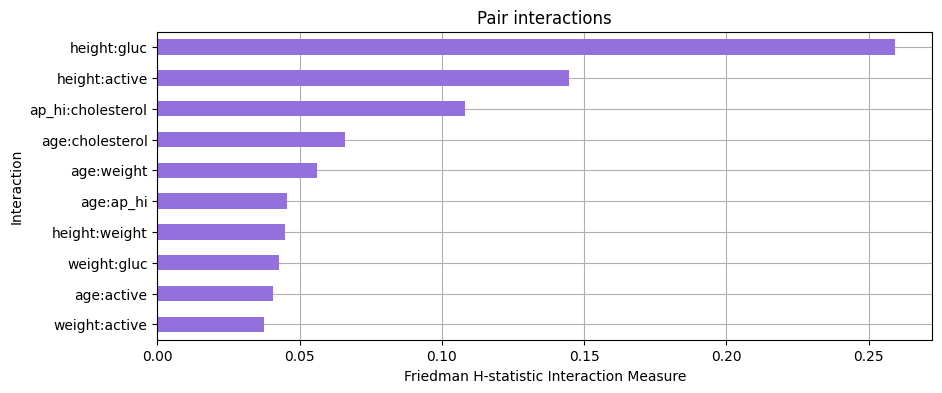

In [ ]:
# Pairwise interactions
fig, ax = plt.subplots(figsize=(10, 4))
h_stat.plot(vis_type='bar_chart',ax=ax)

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=b167ca0cc669e6febbc2df60041e62a7a858bfbf60c5590ff7ceca9078356d0b
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [ ]:
import lime
from lime.lime_tabular import LimeTabularExplainer


In [ ]:
X_train_sel = np.array(X_train_sel)
X_test_sel = np.array(X_test_sel)

In [ ]:
explainer = LimeTabularExplainer(training_data=X_train_sel ,feature_names=feature_names,class_names=['no_disease', 'disease'],mode='classification')

In [ ]:
def predict_fn(x):
    preds = model.predict(x)
    if preds.ndim == 1 or preds.shape[1] == 1:
        preds = preds.flatten()
        return np.stack([1 - preds, preds], axis=1)
    return preds

In [ ]:
i = 1
explanation = explainer.explain_instance(
    data_row=X_test_sel[i],
    predict_fn=predict_fn,
    num_features=10
)

explanation.show_in_notebook()


In [ ]:
i = 3
explanation = explainer.explain_instance(
    data_row=X_test_sel[i],
    predict_fn=predict_fn,
    num_features=10
)

explanation.show_in_notebook()
